In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv("dataset_ml.csv", low_memory=False)

In [3]:
df.head(n=10)

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,resumed,last_alert,next_protocol,established,ssl_history,cert_chain_fps,client_cert_chain_fps,sni_matches_cert,ja3,ja3s
0,1.604696e+09,CkoJoh3ZzDWXikLgXf,10.11.6.101,53163.0,185.114.245.201,80.0,tcp,http,1.860586,76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.604696e+09,CSHTwPrriIQ2WEiMd,10.11.6.101,61145.0,10.11.6.1,53.0,udp,dns,0.232054,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.604696e+09,C1plB236wq3wE524G1,10.11.6.101,53165.0,178.18.200.18,587.0,tcp,smtp,2.115582,3518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.604696e+09,CPquhLn72mADO33c,10.11.6.101,54884.0,10.11.6.1,53.0,udp,dns,0.023294,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.604696e+09,CKSeTh4OLUDm0OSqe4,10.11.6.101,55838.0,10.11.6.1,53.0,udp,dns,0.459046,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.604696e+09,CSS0RGYSyGeDjUIe,10.11.6.101,53164.0,54.235.142.93,80.0,tcp,http,100.122162,63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.604696e+09,CWrsWw3CSiOPxWfhO8,10.11.6.101,53164.0,54.235.142.93,80.0,tcp,-,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.604699e+09,CaML0LsZefGr9JHad,10.11.6.101,53243.0,178.18.200.18,587.0,tcp,smtp,2.142967,2682,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Ch7Uce2mRagDrV8lYa,NaN,NaN,NaN,NaN,udp,dns,0.003001,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Csf7uf2QjMoEIYeCTh,NaN,NaN,NaN,NaN,tcp,"smtp,ssl",102.195326,2642,...,F,-,-,T,CsxknGIi,b4a542ee2352ce99d80ecb55b5686b8f5adf6782aa8f33...,(empty),T,3b5074b1b5d032e5620f69f9f700ff0e,a9e3ed16ee3208291487c8d2aa2ad924


In [4]:
df.describe()

,ts,id.orig_p,id.resp_p,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,ip_proto,ts_x,id.orig_p_x,id.resp_p_x,ts_y,id.orig_p_y,id.resp_p_y
count,1.196250e+05,119625.000000,119625.000000,4.418876e+06,4.418876e+06,4.418876e+06,4.418876e+06,4.418876e+06,4.418876e+06,4.299251e+06,4.299251e+06,4.299251e+06,1.137420e+05,113742.000000,113742.000000
mean,1.762950e+09,50101.912075,19210.094922,2.704645e+03,2.676365e+00,5.201290e+02,2.922652e+00,1.862424e+03,6.075792e+00,1.722819e+09,4.004049e+04,1.168654e+04,1.666196e+09,53475.098354,1176.893425
std,2.045304e+07,11082.799832,20111.833566,1.867975e+06,1.193835e+02,5.039174e+04,2.038625e+02,2.377442e+05,3.342164e+00,4.937388e+07,1.989064e+04,1.722120e+04,5.288793e+07,7001.576492,3490.279871
min,1.579179e+09,3.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.544806e+09,0.000000e+00,0.000000e+00,1.544807e+09,1040.000000,25.000000
25%,1.765987e+09,52743.000000,23.000000,0.000000e+00,1.000000e+00,4.400000e+01,1.000000e+00,4.000000e+01,6.000000e+00,1.717684e+09,3.515600e+04,8.000000e+01,1.632474e+09,50137.000000,443.000000
50%,1.765987e+09,52743.000000,80.000000,0.000000e+00,1.000000e+00,6.000000e+01,1.000000e+00,4.000000e+01,6.000000e+00,1.740893e+09,4.688700e+04,3.702000e+03,1.655408e+09,51975.000000,443.000000
75%,1.765987e+09,52999.000000,37215.000000,0.000000e+00,2.000000e+00,8.000000e+01,1.000000e+00,4.000000e+01,6.000000e+00,1.762185e+09,5.401800e+04,1.251100e+04,1.683056e+09,57727.000000,443.000000
max,1.776109e+09,65529.000000,60346.000000,2.126478e+09,1.819790e+05,3.937376e+07,2.168560e+05,2.119881e+08,1.320000e+02,1.781294e+09,6.553500e+04,6.553500e+04,1.781294e+09,65534.000000,65281.000000


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
df["label"].value_counts()

label
BACKGROUND_NOISE    3550908
HANCITOR             276225
MIRAI                115826
ICEDID               109222
QAKBOT                68231
EMOTET                68103
REDTAIL               40804
ASTAROTH              31122
GOZI                  25121
FORMBOOK              14106
BENIGN5               14013
BAZARLOADER           11587
DARKGATE               9477
UNKNOWN                9202
SQUIRRELWAFFLE         7269
BENIGN4                7177
TRICKBOT               7119
PIKABOT                6865
XLOADER                5654
BENIGN3                4728
MATANBUCHUS            4094
BUMBLEBEE              3748
LUMMA                  3194
BENIGN2                3039
VALAK                  2934
ZLOADER                2224
BENIGN                 1715
LATRODECTUS            1597
DRIDEX                 1429
KONGTUKE               1152
KOI                    1083
SVCREADY                967
REMCOS                  800
NET_SUPPORT_RAT         688
REDLINE                 673
AMOS          

In [6]:
df['label'] = df['label'].apply(
    lambda x: 'BENIGN' if str(x).startswith('BENIGN') else x
)

In [7]:
tls_cols = [
    'ts_y',
    'id.orig_h_y',
    'id.orig_p_y',
    'id.resp_h_y',
    'id.resp_p_y',
    'version',
    'cipher',
    'curve',
    'server_name',
    'resumed',
    'last_alert',
    'next_protocol',
    'established',
    'ssl_history',
    'cert_chain_fps',
    'client_cert_chain_fps',
    'sni_matches_cert',
    'ja3',
    'ja3s'
]
df = df.drop(
    columns=tls_cols,
    errors='ignore'
)

In [8]:
df.dtypes

ts                float64
uid                object
id.orig_h          object
id.orig_p         float64
id.resp_h          object
id.resp_p         float64
proto              object
service            object
duration           object
orig_bytes         object
resp_bytes         object
conn_state         object
local_orig         object
local_resp         object
missed_bytes        int64
history            object
orig_pkts           int64
orig_ip_bytes       int64
resp_pkts           int64
resp_ip_bytes       int64
tunnel_parents     object
ip_proto            int64
label              object
ts_x              float64
id.orig_h_x        object
id.orig_p_x       float64
id.resp_h_x        object
id.resp_p_x       float64
dtype: object

In [9]:
print(df.columns)

Index(['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
       'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
       'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history',
       'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes',
       'tunnel_parents', 'ip_proto', 'label', 'ts_x', 'id.orig_h_x',
       'id.orig_p_x', 'id.resp_h_x', 'id.resp_p_x'],
      dtype='object')


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4418876 entries, 0 to 4418875
Data columns (total 28 columns):
 #   Column          Dtype  
---  ------          -----  
 0   ts              float64
 1   uid             object 
 2   id.orig_h       object 
 3   id.orig_p       float64
 4   id.resp_h       object 
 5   id.resp_p       float64
 6   proto           object 
 7   service         object 
 8   duration        object 
 9   orig_bytes      object 
 10  resp_bytes      object 
 11  conn_state      object 
 12  local_orig      object 
 13  local_resp      object 
 14  missed_bytes    int64  
 15  history         object 
 16  orig_pkts       int64  
 17  orig_ip_bytes   int64  
 18  resp_pkts       int64  
 19  resp_ip_bytes   int64  
 20  tunnel_parents  object 
 21  ip_proto        int64  
 22  label           object 
 23  ts_x            float64
 24  id.orig_h_x     object 
 25  id.orig_p_x     float64
 26  id.resp_h_x     object 
 27  id.resp_p_x     float64
dtypes: float64(6

In [11]:
print(df.isnull().sum())

ts                4299251
uid                     0
id.orig_h         4299251
id.orig_p         4299251
id.resp_h         4299251
id.resp_p         4299251
proto                   0
service                 0
duration                0
orig_bytes              0
resp_bytes              0
conn_state              0
local_orig              0
local_resp              0
missed_bytes            0
history                 0
orig_pkts               0
orig_ip_bytes           0
resp_pkts               0
resp_ip_bytes           0
tunnel_parents          0
ip_proto                0
label                   0
ts_x               119625
id.orig_h_x        119625
id.orig_p_x        119625
id.resp_h_x        119625
id.resp_p_x        119625
dtype: int64


In [12]:
drop_cols = [
    'uid',
    'ts_x', 'ts_y', 'ts',
    'id.orig_h_x', 'id.orig_h_y', 'id.orig_h',
    'id.resp_h_x', 'id.resp_h_y', 'id.resp_h',
    'id.orig_p_x', 'id.orig_p_y',
    'id.resp_p_x', 'id.resp_p_y',
    'id.orig_p',
    'id.resp_p'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [13]:
bool_cols = [
    'local_orig',
    'local_resp'
]

mapping = {
    'T': 1,
    'F': 0,
    '-': 0
}

for col in bool_cols:
    if col in df.columns:

        df[col] = (
            df[col]
            .fillna('F')
            .astype(str)
            .map(mapping)
            .fillna(0)
            .astype(int)
        )

In [14]:
for col in bool_cols:
    print(col)
    print(df[col].value_counts(dropna=False))

local_orig
local_orig
0    3561283
1     857593
Name: count, dtype: int64
local_resp
local_resp
0    4000090
1     418786
Name: count, dtype: int64


In [15]:
high_cardinality = [
    'server_name',
    'ja3',
    'ja3s'
]

for col in high_cardinality:
    if col in df.columns:
        print(col, df[col].nunique())

In [16]:
freq_cols = [
    'server_name',
    'ja3',
    'ja3s'
]

for col in freq_cols:
    if col in df.columns:

        freq = df[col].value_counts()

        df[col + '_freq'] = df[col].map(freq)

        df.drop(
            columns=[col],
            inplace=True
        )

In [17]:
df.select_dtypes(include='object').columns

Index(['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
       'conn_state', 'history', 'tunnel_parents', 'label'],
      dtype='object')

In [18]:
df = df.drop(
    columns=[
        'cert_chain_fps',
        'client_cert_chain_fps'
    ],
    errors='ignore'
)

In [19]:
df = df.fillna('NO_VALUE')

In [20]:
df = df.drop(
    columns=[
        'cert_chain_fps',
        'client_cert_chain_fps'
    ],
    errors='ignore'
)

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()


df["label_encoded"] = label_encoder.fit_transform(
    df["label"].astype(str)
)
cat_cols = df.select_dtypes(
    include=['object']
).columns
cat_cols = cat_cols.drop("label")


for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [22]:

target_per_class = 5000

df_small = (
    df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_per_class),
        random_state=42
    ))
)

print(df_small["label"].value_counts())

label
DARKGATE            5000
BENIGN              5000
REDTAIL             5000
FORMBOOK            5000
EMOTET              5000
HANCITOR            5000
ICEDID              5000
SQUIRRELWAFFLE      5000
GOZI                5000
PIKABOT             5000
BAZARLOADER         5000
TRICKBOT            5000
BACKGROUND_NOISE    5000
UNKNOWN             5000
MIRAI               5000
ASTAROTH            5000
XLOADER             5000
QAKBOT              5000
MATANBUCHUS         4094
BUMBLEBEE           3748
LUMMA               3194
VALAK               2934
ZLOADER             2224
LATRODECTUS         1597
DRIDEX              1429
KONGTUKE            1152
KOI                 1083
SVCREADY             967
REMCOS               800
NET_SUPPORT_RAT      688
REDLINE              673
AMOS                 635
GOOTLOADER           609
SYSTEMBC             515
STEALC               506
NJRAT                497
GHOSTWEAVER          463
ANDROID              413
PURPLEFOX            404
MIRRRORBLAST       

C:\Users\marco\AppData\Local\Temp\ipykernel_22376\1708598998.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [23]:
X = df.drop(
    columns=['label']
)

y = df['label']

In [24]:
from sklearn.model_selection import train_test_split

X = df_small.drop(
    columns=[
        "label",
        "label_encoded"
    ]
)

y = df_small["label"]

mask = y.notna()
X = X[mask]
y = y[mask]
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(X_train, y_train)

scores = pd.Series(mi, index=X_train.columns)
scores = scores.sort_values(ascending=False)
scores_sorted = scores.sort_values(ascending=False)
selected_features = scores[scores > 0.05].index

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

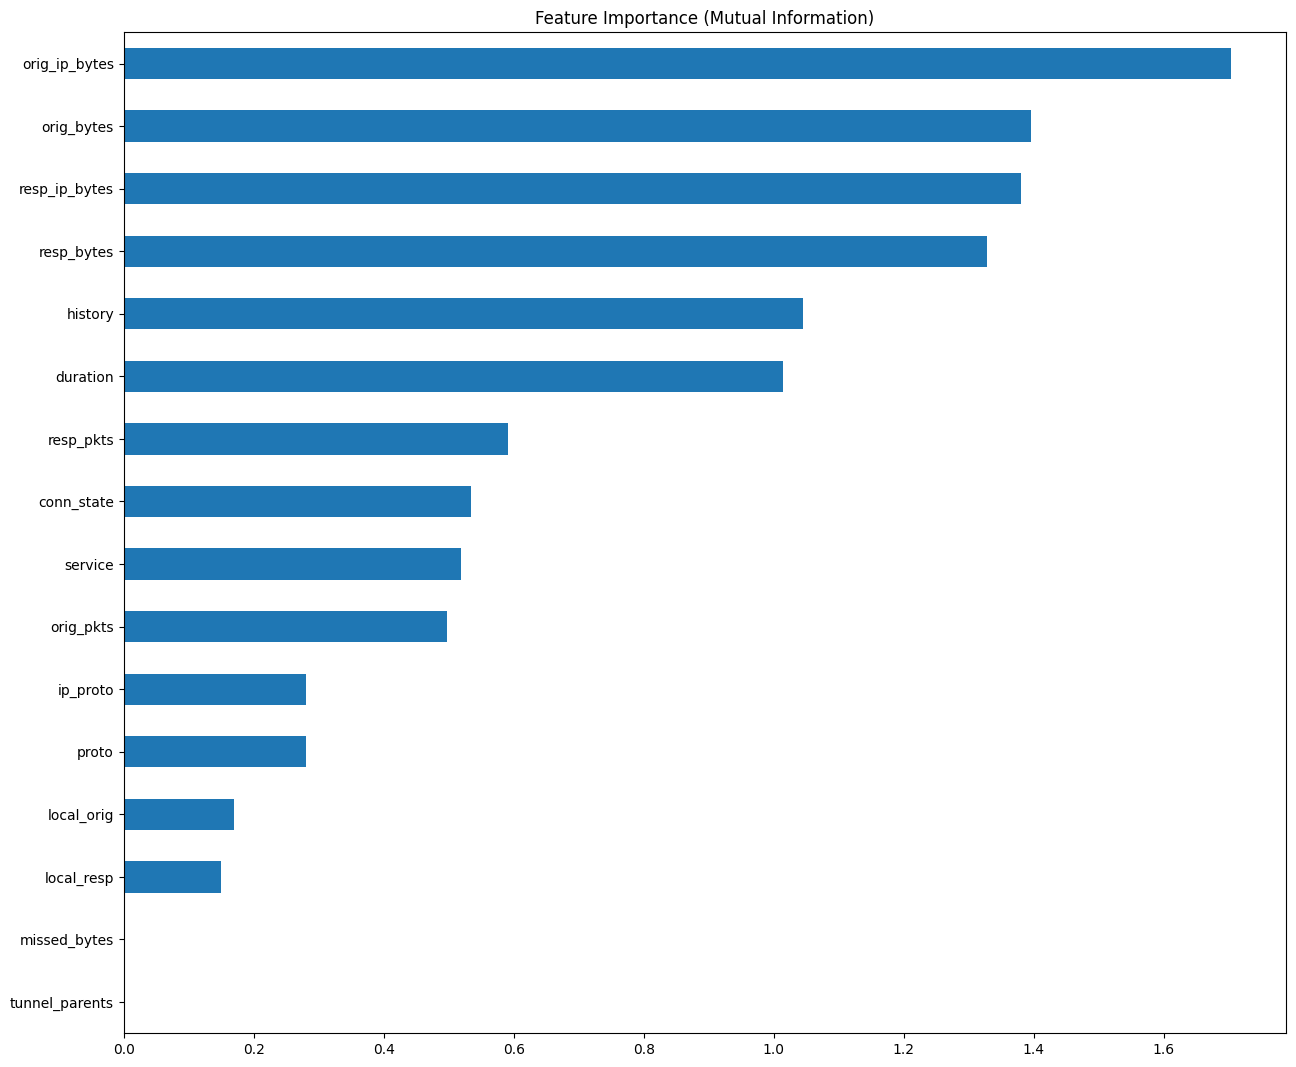

In [26]:
import matplotlib.pyplot as plt

scores_sorted.plot(kind='barh', figsize=(15,13))
plt.gca().invert_yaxis()
plt.title("Feature Importance (Mutual Information)")
plt.show()

In [27]:
from imblearn.over_sampling import RandomOverSampler


ros = RandomOverSampler(
    random_state=42
)


X_train_bal, y_train_bal = ros.fit_resample(
    X_train_sel,
    y_train
)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=40,
    max_features='sqrt',
    random_state=0,
    n_jobs=-1
)


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


print('Random Forest Model')


cv_rf = cross_val_score(
    rf,
    X_train_bal,
    y_train_bal,
    cv=cv,
    n_jobs=1
)


print(f'\nCross-validation scores: {cv_rf}')
print(f'Mean cross-validation score: {cv_rf.mean():.4f}')

Random Forest Model

Cross-validation scores: [0.88633295 0.88827103 0.88619245]
Mean cross-validation score: 0.8869


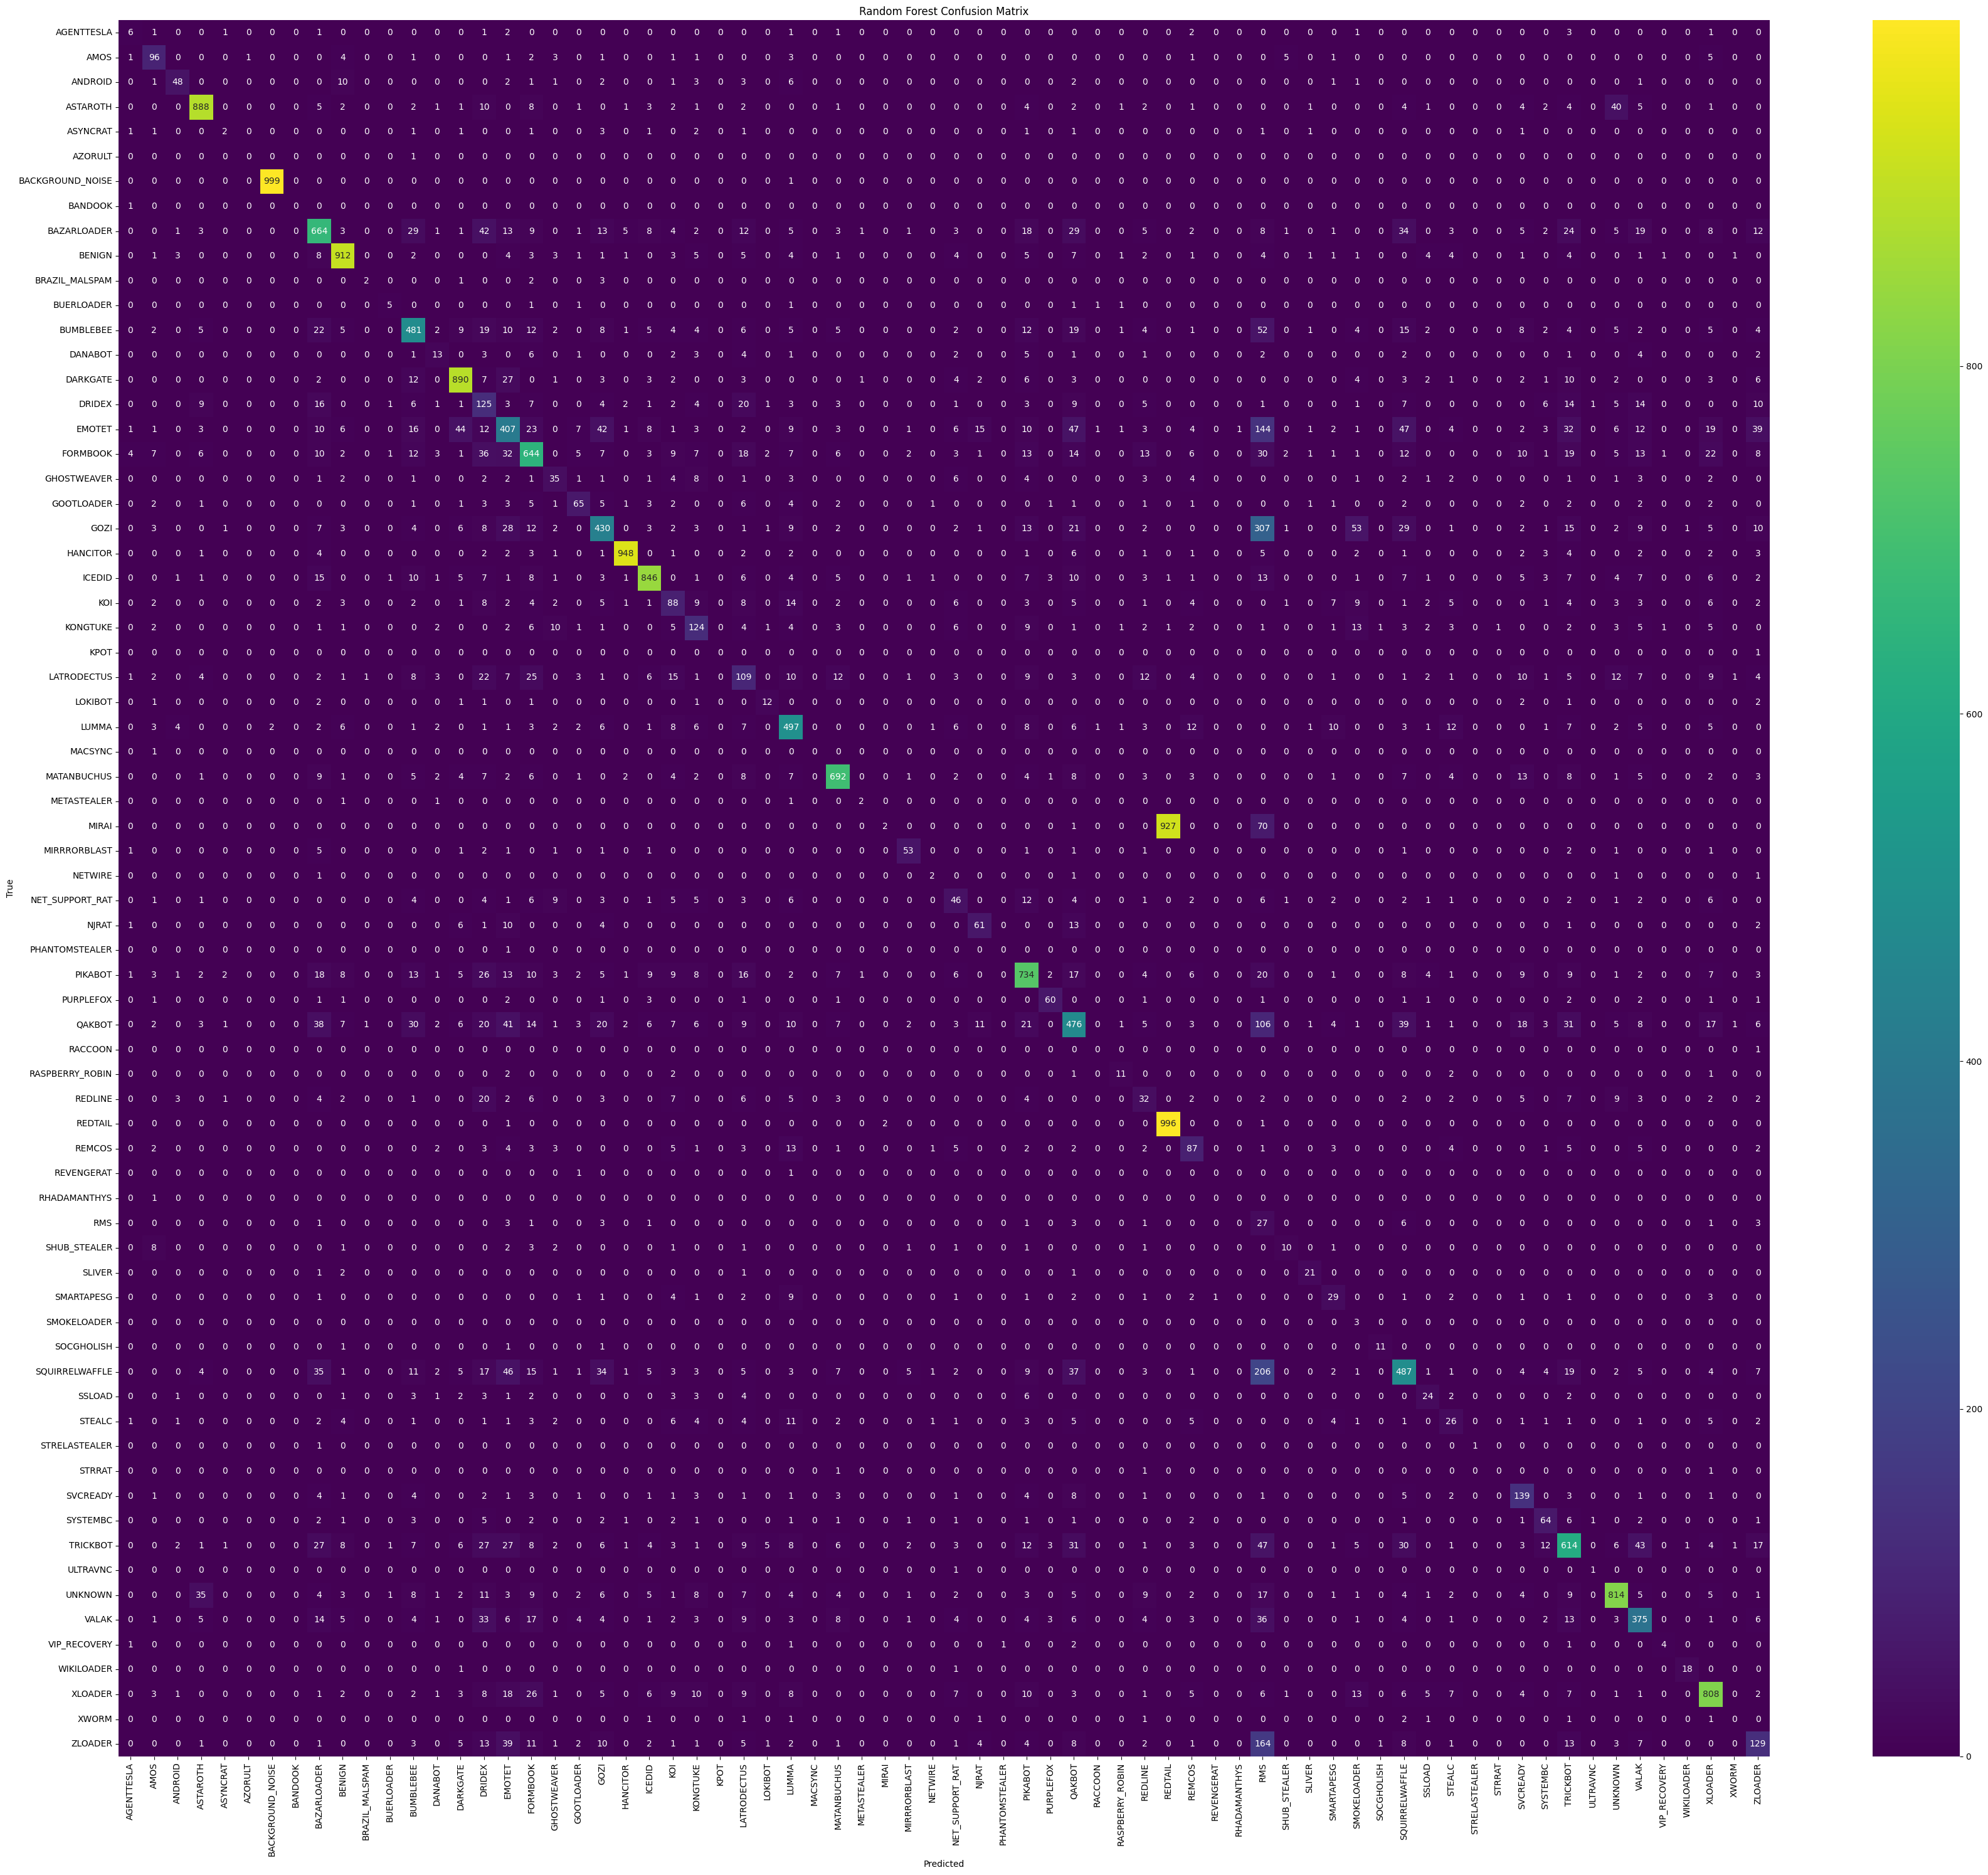

['modelo_sintls.pkl']

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

rf.fit(
    X_train_bal,
    y_train_bal
)
y_pred_rf = rf.predict(
    X_test_sel
)

y_test_names = y_test
y_pred_names = y_pred_rf
labels = sorted(
    list(set(y_test_names))
)

cm = confusion_matrix(
    y_test_names,
    y_pred_names,
    labels=labels
)


cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)


plt.figure(
    figsize=(35,30)
)


sns.heatmap(
    cm_df,
    cmap="viridis",
    annot=True,
    fmt="d"
)


plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")


plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

joblib.dump(rf, "modelo_sintls.pkl")

In [30]:
from sklearn.metrics import classification_report
import numpy as np
import plotly.express as px
import pandas as pd


y_pred_rf = rf.predict(
    X_test_sel
)

target_names = sorted(
    list(set(y_test))
)

metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_rf,
    labels=target_names,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)


# Métricas
precision = [
    metrics[c]['precision']
    for c in target_names
]


recall = [
    metrics[c]['recall']
    for c in target_names
]


f1 = [
    metrics[c]['f1-score']
    for c in target_names
]

display_names = [
    'BENIGN' if str(c).startswith('BENIGN') else c
    for c in target_names
]

data = np.array([
    precision,
    recall,
    f1
])


heatmap_df = pd.DataFrame(
    data,
    index=[
        'Precision',
        'Recall',
        'F1-score'
    ],
    columns=display_names
)


fig = px.imshow(
    heatmap_df,
    text_auto='.3f',
    aspect="auto",
    color_continuous_scale='Viridis'
)


fig.update_layout(
    title="Random Forest - Classification Report",
    width=2500,
    height=600,
    xaxis=dict(
        tickangle=45
    )
)


fig.write_html(
    "classification_report_RF_sintls.html"
)

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


dt = DecisionTreeClassifier(
    max_depth=40,
    min_samples_leaf=2,
    random_state=0
)


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


print('Decision Tree Model')


cv_rf = cross_val_score(
    dt,
    X_train_bal,
    y_train_bal,
    cv=cv,
    n_jobs=1
)


print(f'\nCross-validation scores: {cv_rf}')
print(f'Mean cross-validation score: {cv_rf.mean():.4f}')

Decision Tree Model

Cross-validation scores: [0.860276   0.85966378 0.85659949]
Mean cross-validation score: 0.8588


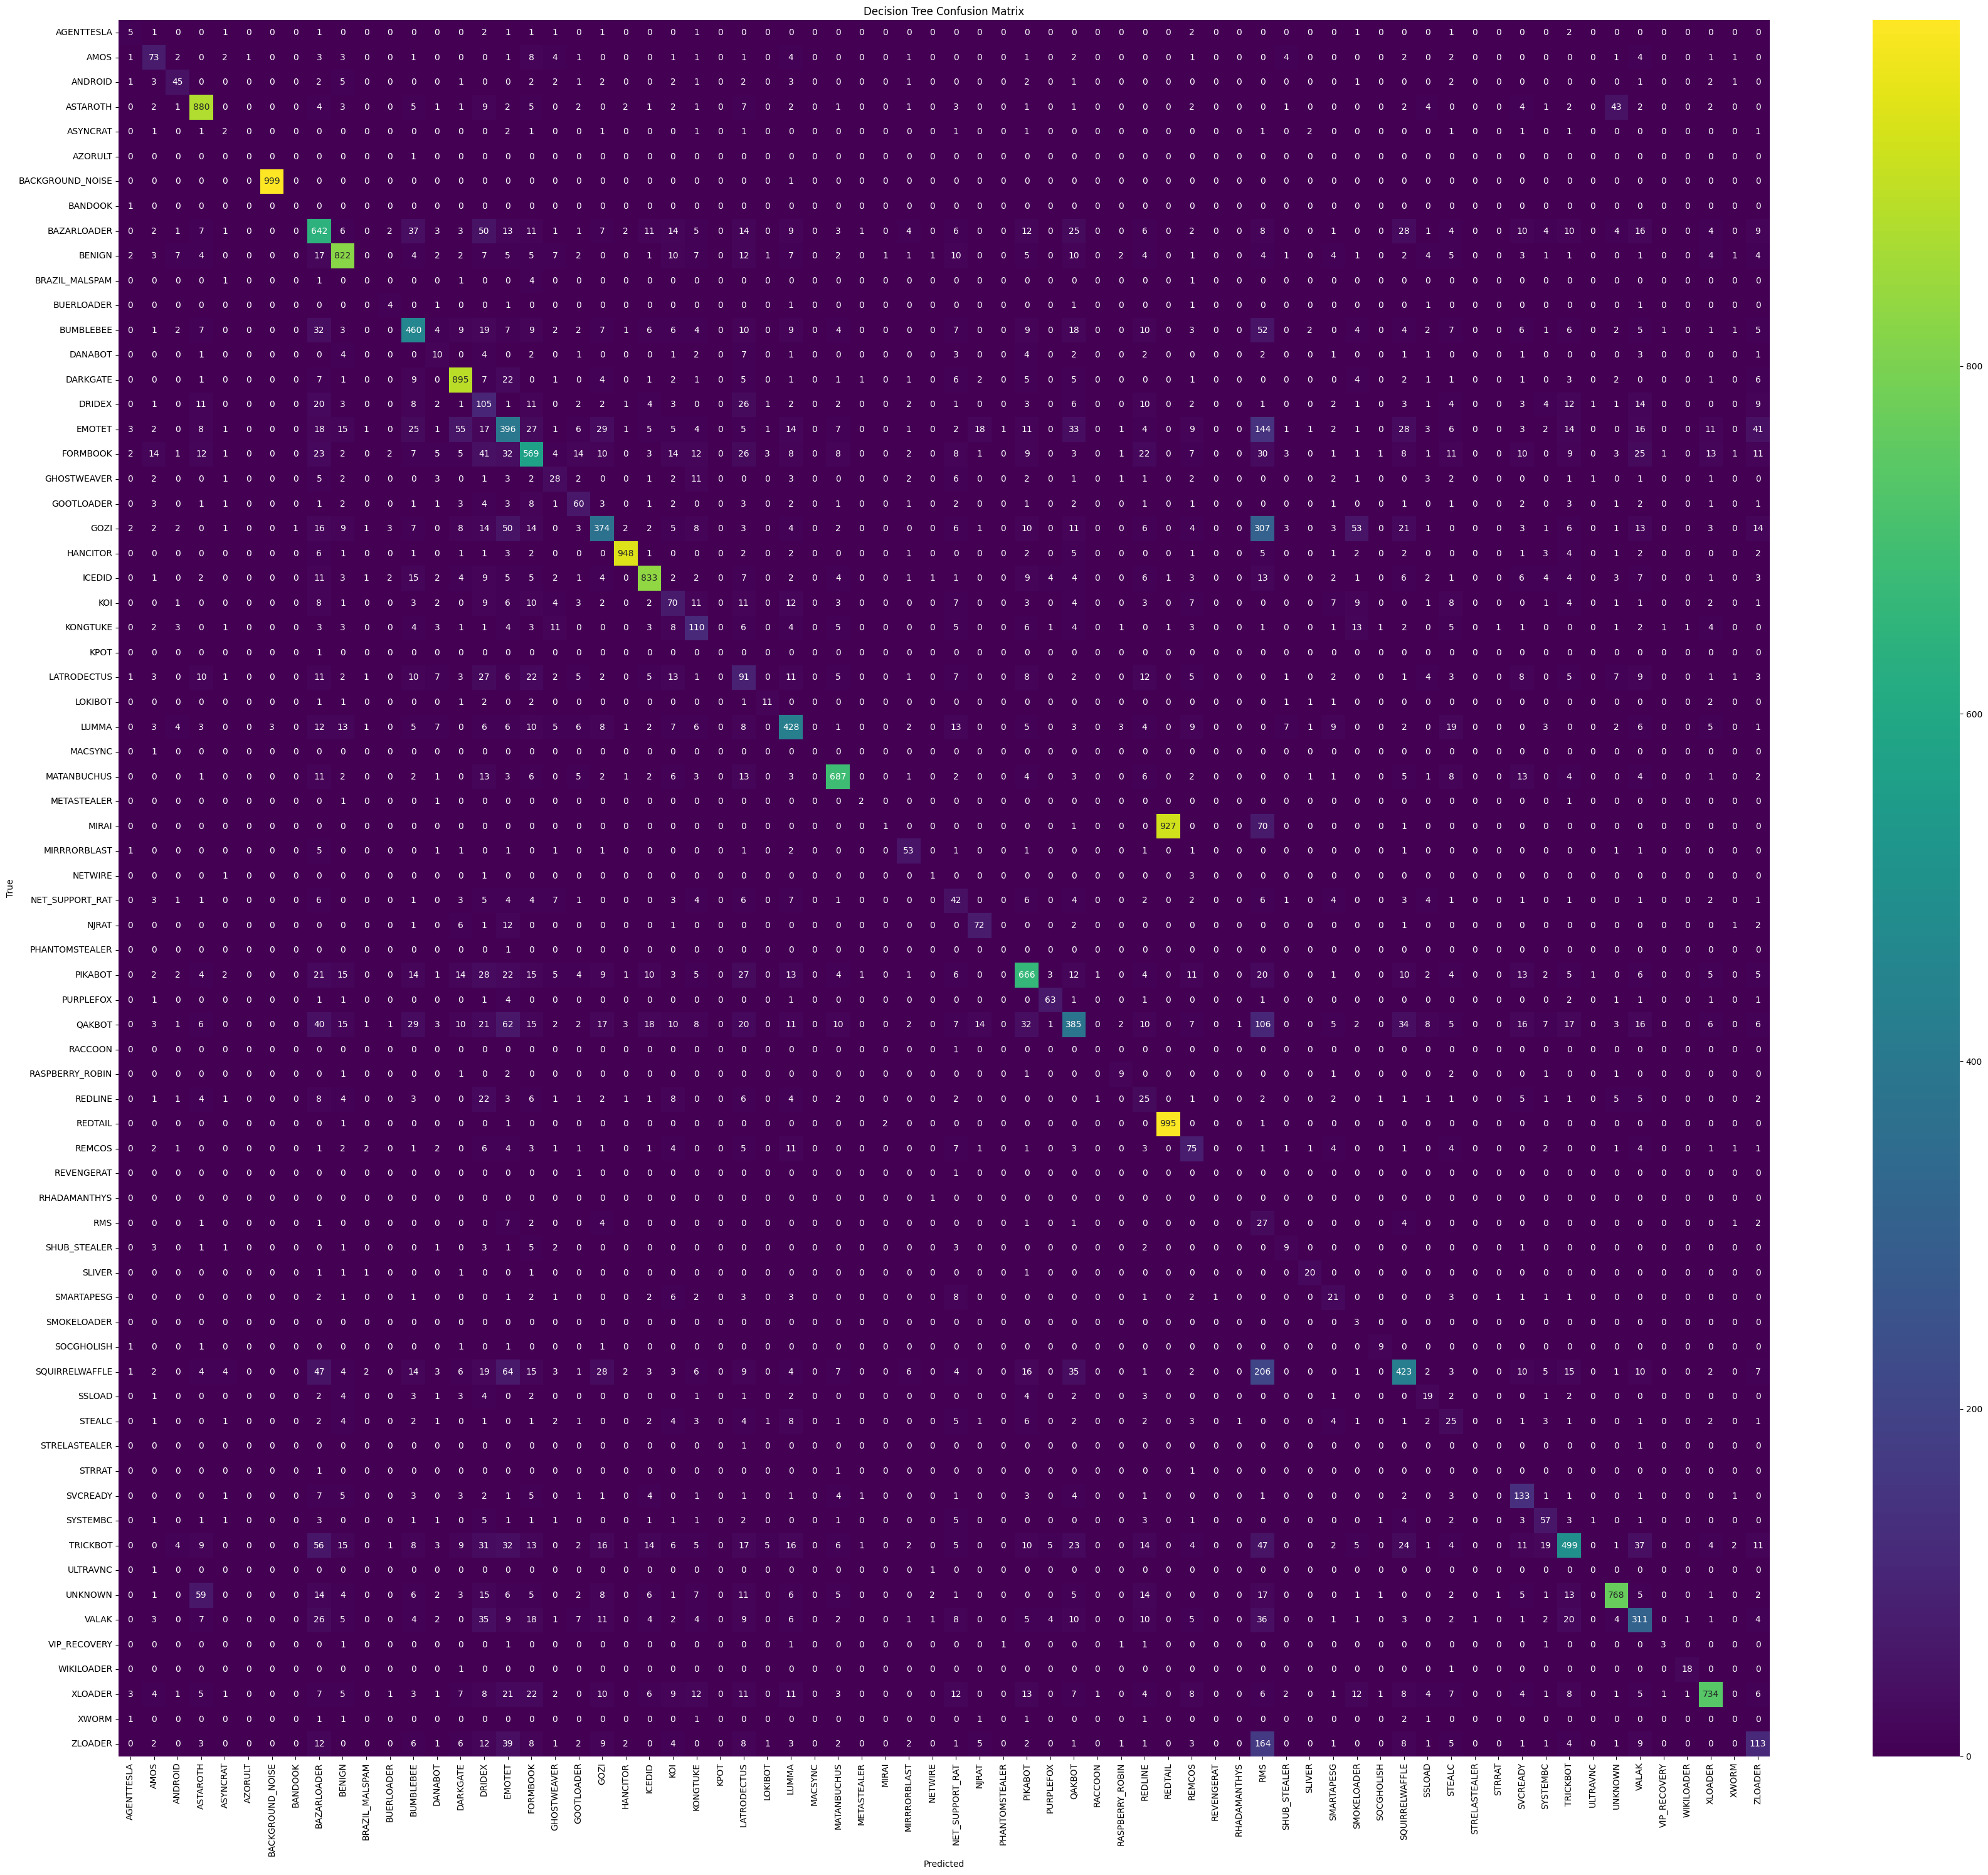

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dt.fit(X_train_bal, y_train_bal)
y_pred_dt = dt.predict(X_test_sel)
labels = dt.classes_   
cm = confusion_matrix(y_test, y_pred_dt, labels=labels)

plt.figure(figsize=(35, 30))

sns.heatmap(
    cm,
    cmap="viridis",   
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report
import numpy as np
import plotly.express as px
import pandas as pd


y_pred_dt = dt.predict(X_test_sel)
target_names = sorted(set(y_test) | set(y_pred_dt))
metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_dt,
    labels=target_names,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)


# Métricas
precision = [
    metrics[c]['precision']
    for c in target_names
]

recall = [
    metrics[c]['recall']
    for c in target_names
]

f1 = [
    metrics[c]['f1-score']
    for c in target_names
]

display_names = [
    'BENIGN' if str(c).startswith('BENIGN') else c
    for c in target_names
]

data = np.array([
    precision,
    recall,
    f1
])


heatmap_df = pd.DataFrame(
    data,
    index=[
        'Precision',
        'Recall',
        'F1-score'
    ],
    columns=display_names
)


fig = px.imshow(
    heatmap_df,
    text_auto='.3f',
    aspect="auto",
    color_continuous_scale='Viridis'
)


fig.update_layout(
    title="Decision Tree - Classification Report",
    width=2500,
    height=600,
    xaxis=dict(
        tickangle=45
    )
)


fig.write_html(
    "classification_report_DT_sintls.html"
)



In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_sel)

k_values = [3, 5, 7, 9, 11, 15]

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv_knn_k = cross_val_score(
        knn_k, X_train_scaled, y_train_bal, cv=3, n_jobs=1
    )
    print(f'KNN k={k}: CV scores={cv_knn_k}, Mean={cv_knn_k.mean():.4f}')

KNN k=3: CV scores=[0.84992607 0.85561377 0.85686735], Mean=0.8541
KNN k=5: CV scores=[0.83687617 0.83752799 0.841053  ], Mean=0.8385
KNN k=7: CV scores=[0.82150127 0.82558152 0.82636367], Mean=0.8245
KNN k=9: CV scores=[0.80893351 0.81141718 0.81252076], Mean=0.8110
KNN k=11: CV scores=[0.7961836  0.79927785 0.79996357], Mean=0.7985
KNN k=15: CV scores=[0.77739088 0.77857778 0.77834207], Mean=0.7781


In [35]:
# Modelo KNN final con el mejor k
knn = KNeighborsClassifier(n_neighbors=3)

print("KNN Model (k=3)")

cv_knn = cross_val_score(
    knn, X_train_scaled, y_train_bal, cv=3, n_jobs=-1
)

print(f"CV scores: {cv_knn}")
print(f"Mean accuracy: {cv_knn.mean():.4f}")


KNN Model (k=3)
CV scores: [0.84992607 0.85561377 0.85686735]
Mean accuracy: 0.8541


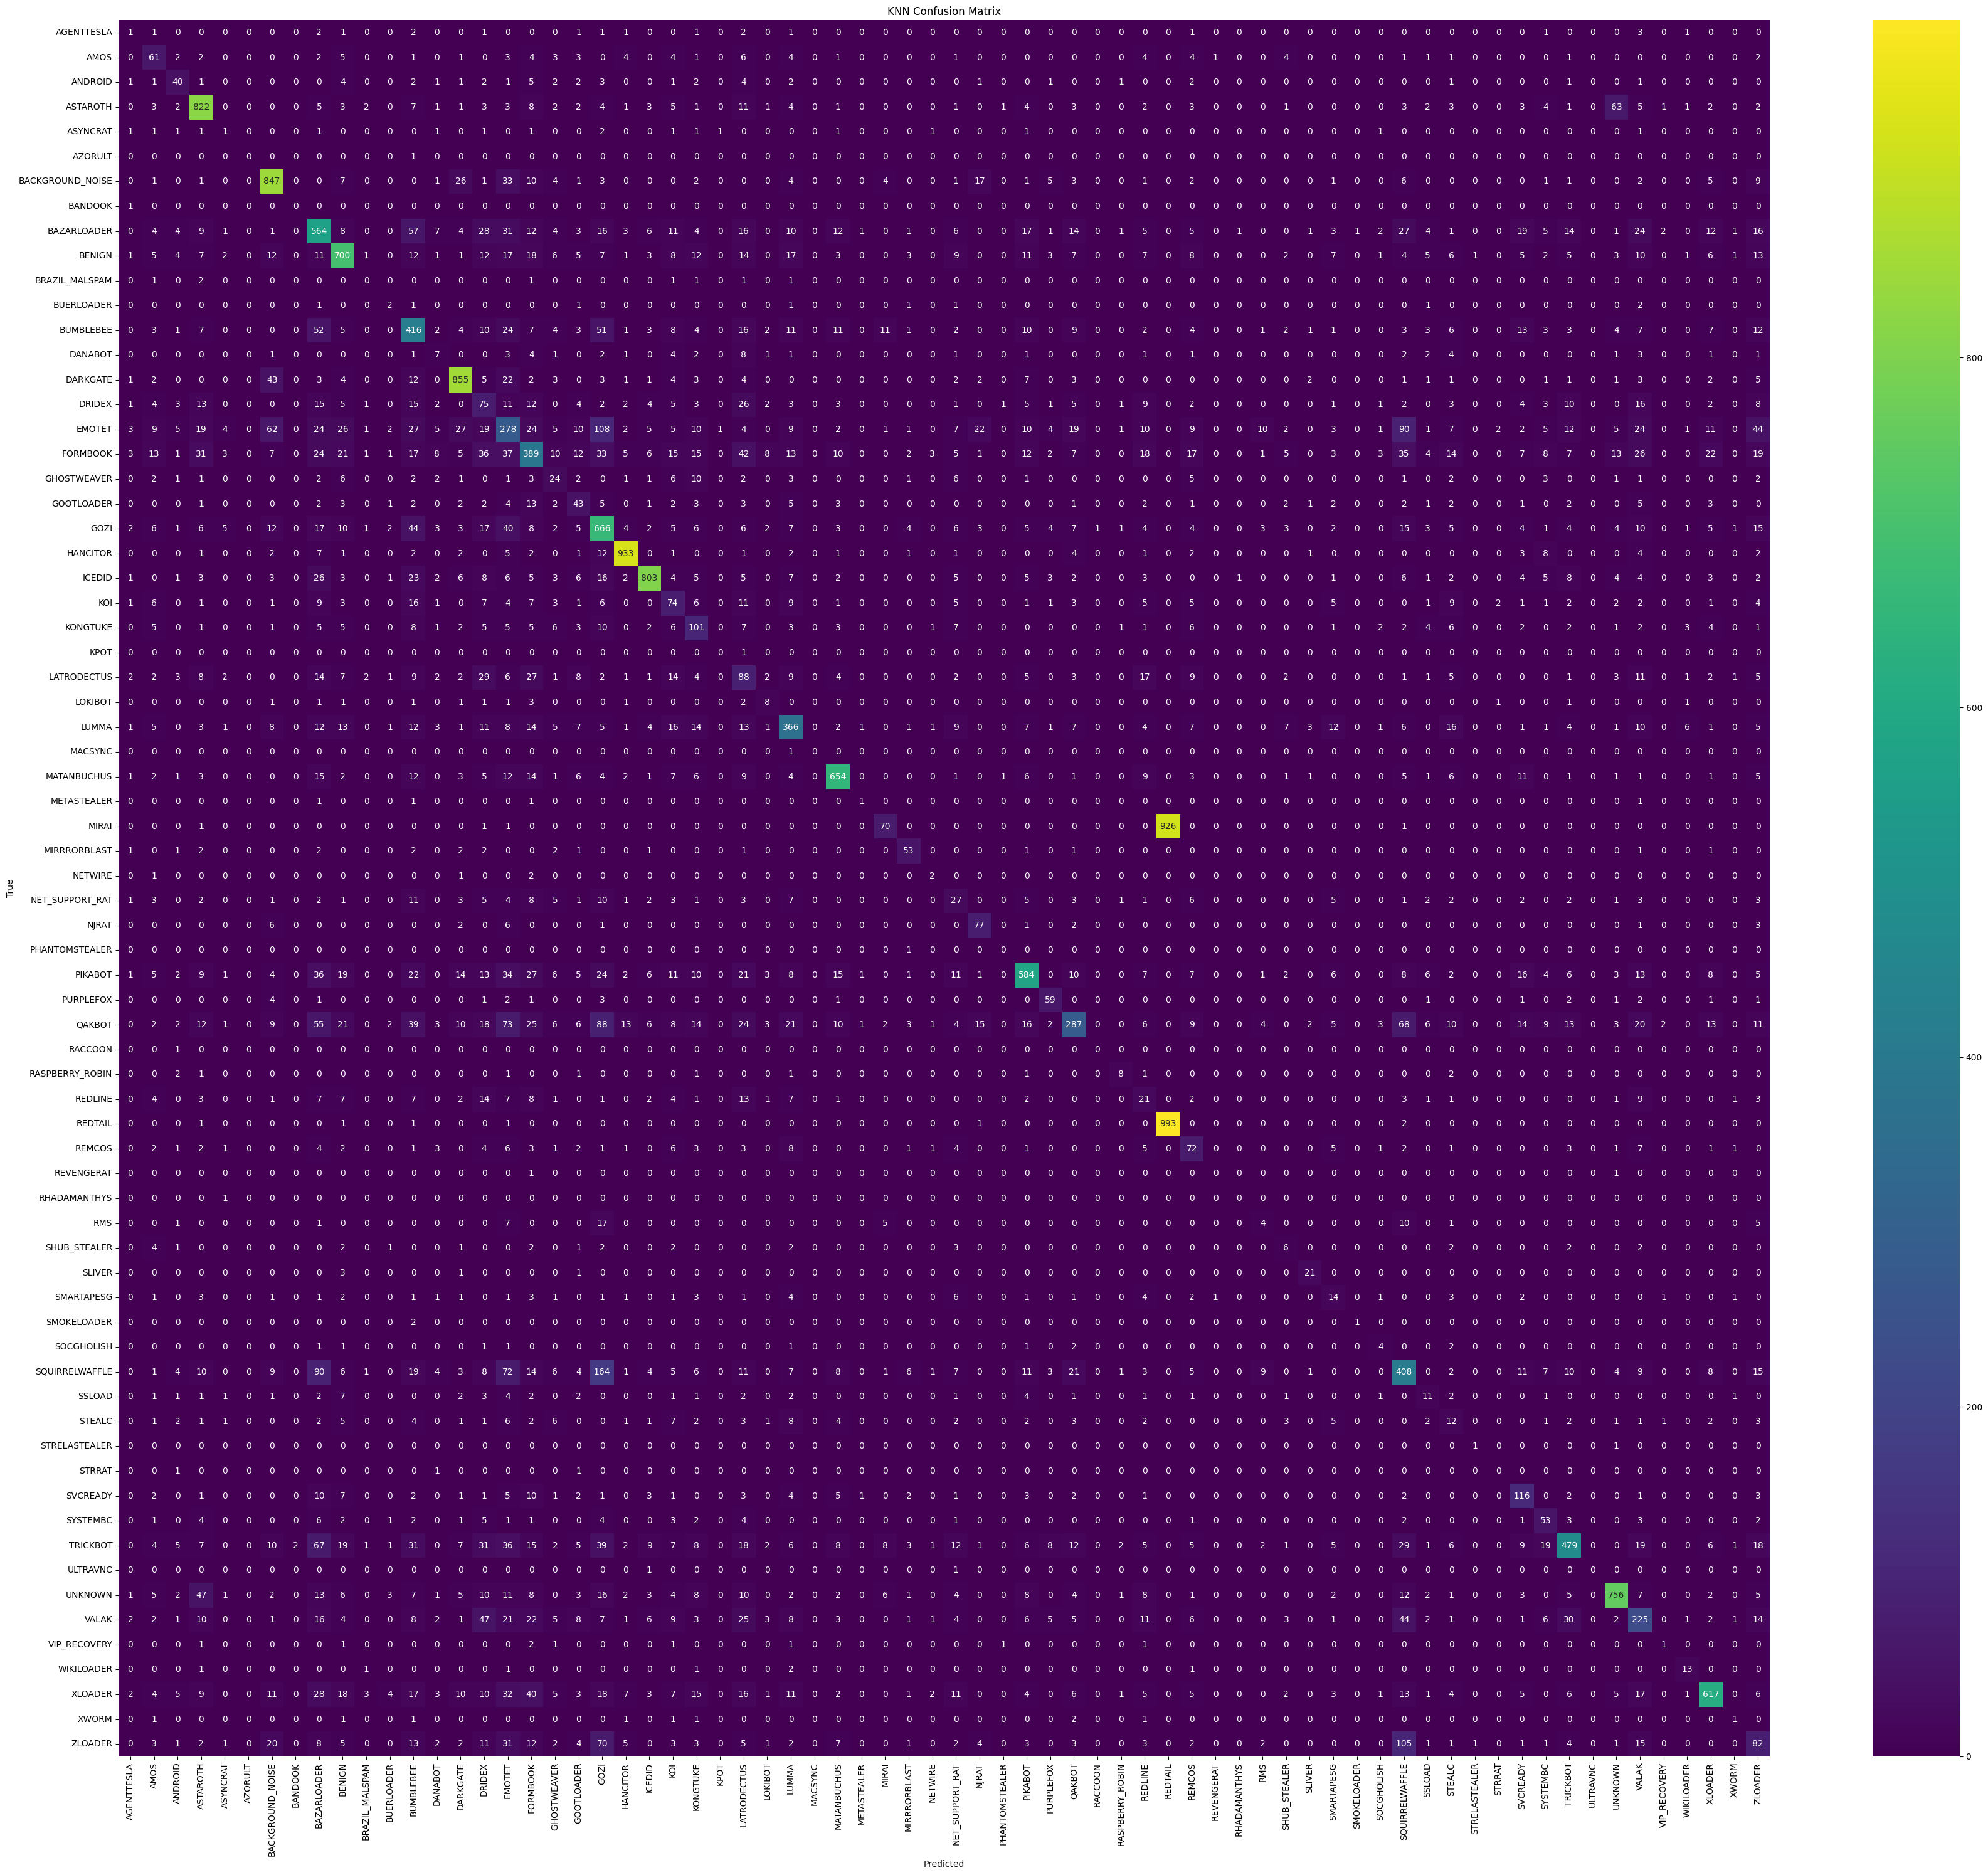

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

knn.fit(X_train_bal, y_train_bal)
y_pred_knn = knn.predict(X_test_sel)
labels = knn.classes_   
cm = confusion_matrix(y_test, y_pred_knn, labels=labels)

plt.figure(figsize=(35, 30))

sns.heatmap(
    cm,
    cmap="viridis",   
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import classification_report
import numpy as np
import plotly.express as px
import pandas as pd


y_pred_knn = knn.predict(X_test_sel)
target_names = sorted(set(y_test) | set(y_pred_knn))
metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_knn,
    labels=target_names,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)


# Métricas
precision = [
    metrics[c]['precision']
    for c in target_names
]

recall = [
    metrics[c]['recall']
    for c in target_names
]

f1 = [
    metrics[c]['f1-score']
    for c in target_names
]

display_names = [
    'BENIGN' if str(c).startswith('BENIGN') else c
    for c in target_names
]

data = np.array([
    precision,
    recall,
    f1
])


heatmap_df = pd.DataFrame(
    data,
    index=[
        'Precision',
        'Recall',
        'F1-score'
    ],
    columns=display_names
)


fig = px.imshow(
    heatmap_df,
    text_auto='.3f',
    aspect="auto",
    color_continuous_scale='Viridis'
)


fig.update_layout(
    title="KNN - Classification Report",
    width=2500,
    height=600,
    xaxis=dict(
        tickangle=45
    )
)


fig.write_html(
    "classification_report_KNN_sintls.html"
)



In [38]:
from lightgbm import LGBMClassifier


lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


print('LGBM Model')


cv_lg = cross_val_score(    
    lgbm,
    X_train_bal,
    y_train_bal,
    cv=cv,
    n_jobs=1
)


print(f'\nCross-validation scores: {cv_lg}')
print(f'Mean cross-validation score: {cv_lg.mean():.4f}')

LGBM Model

Cross-validation scores: [0.86070457 0.8613995  0.85978164]
Mean cross-validation score: 0.8606


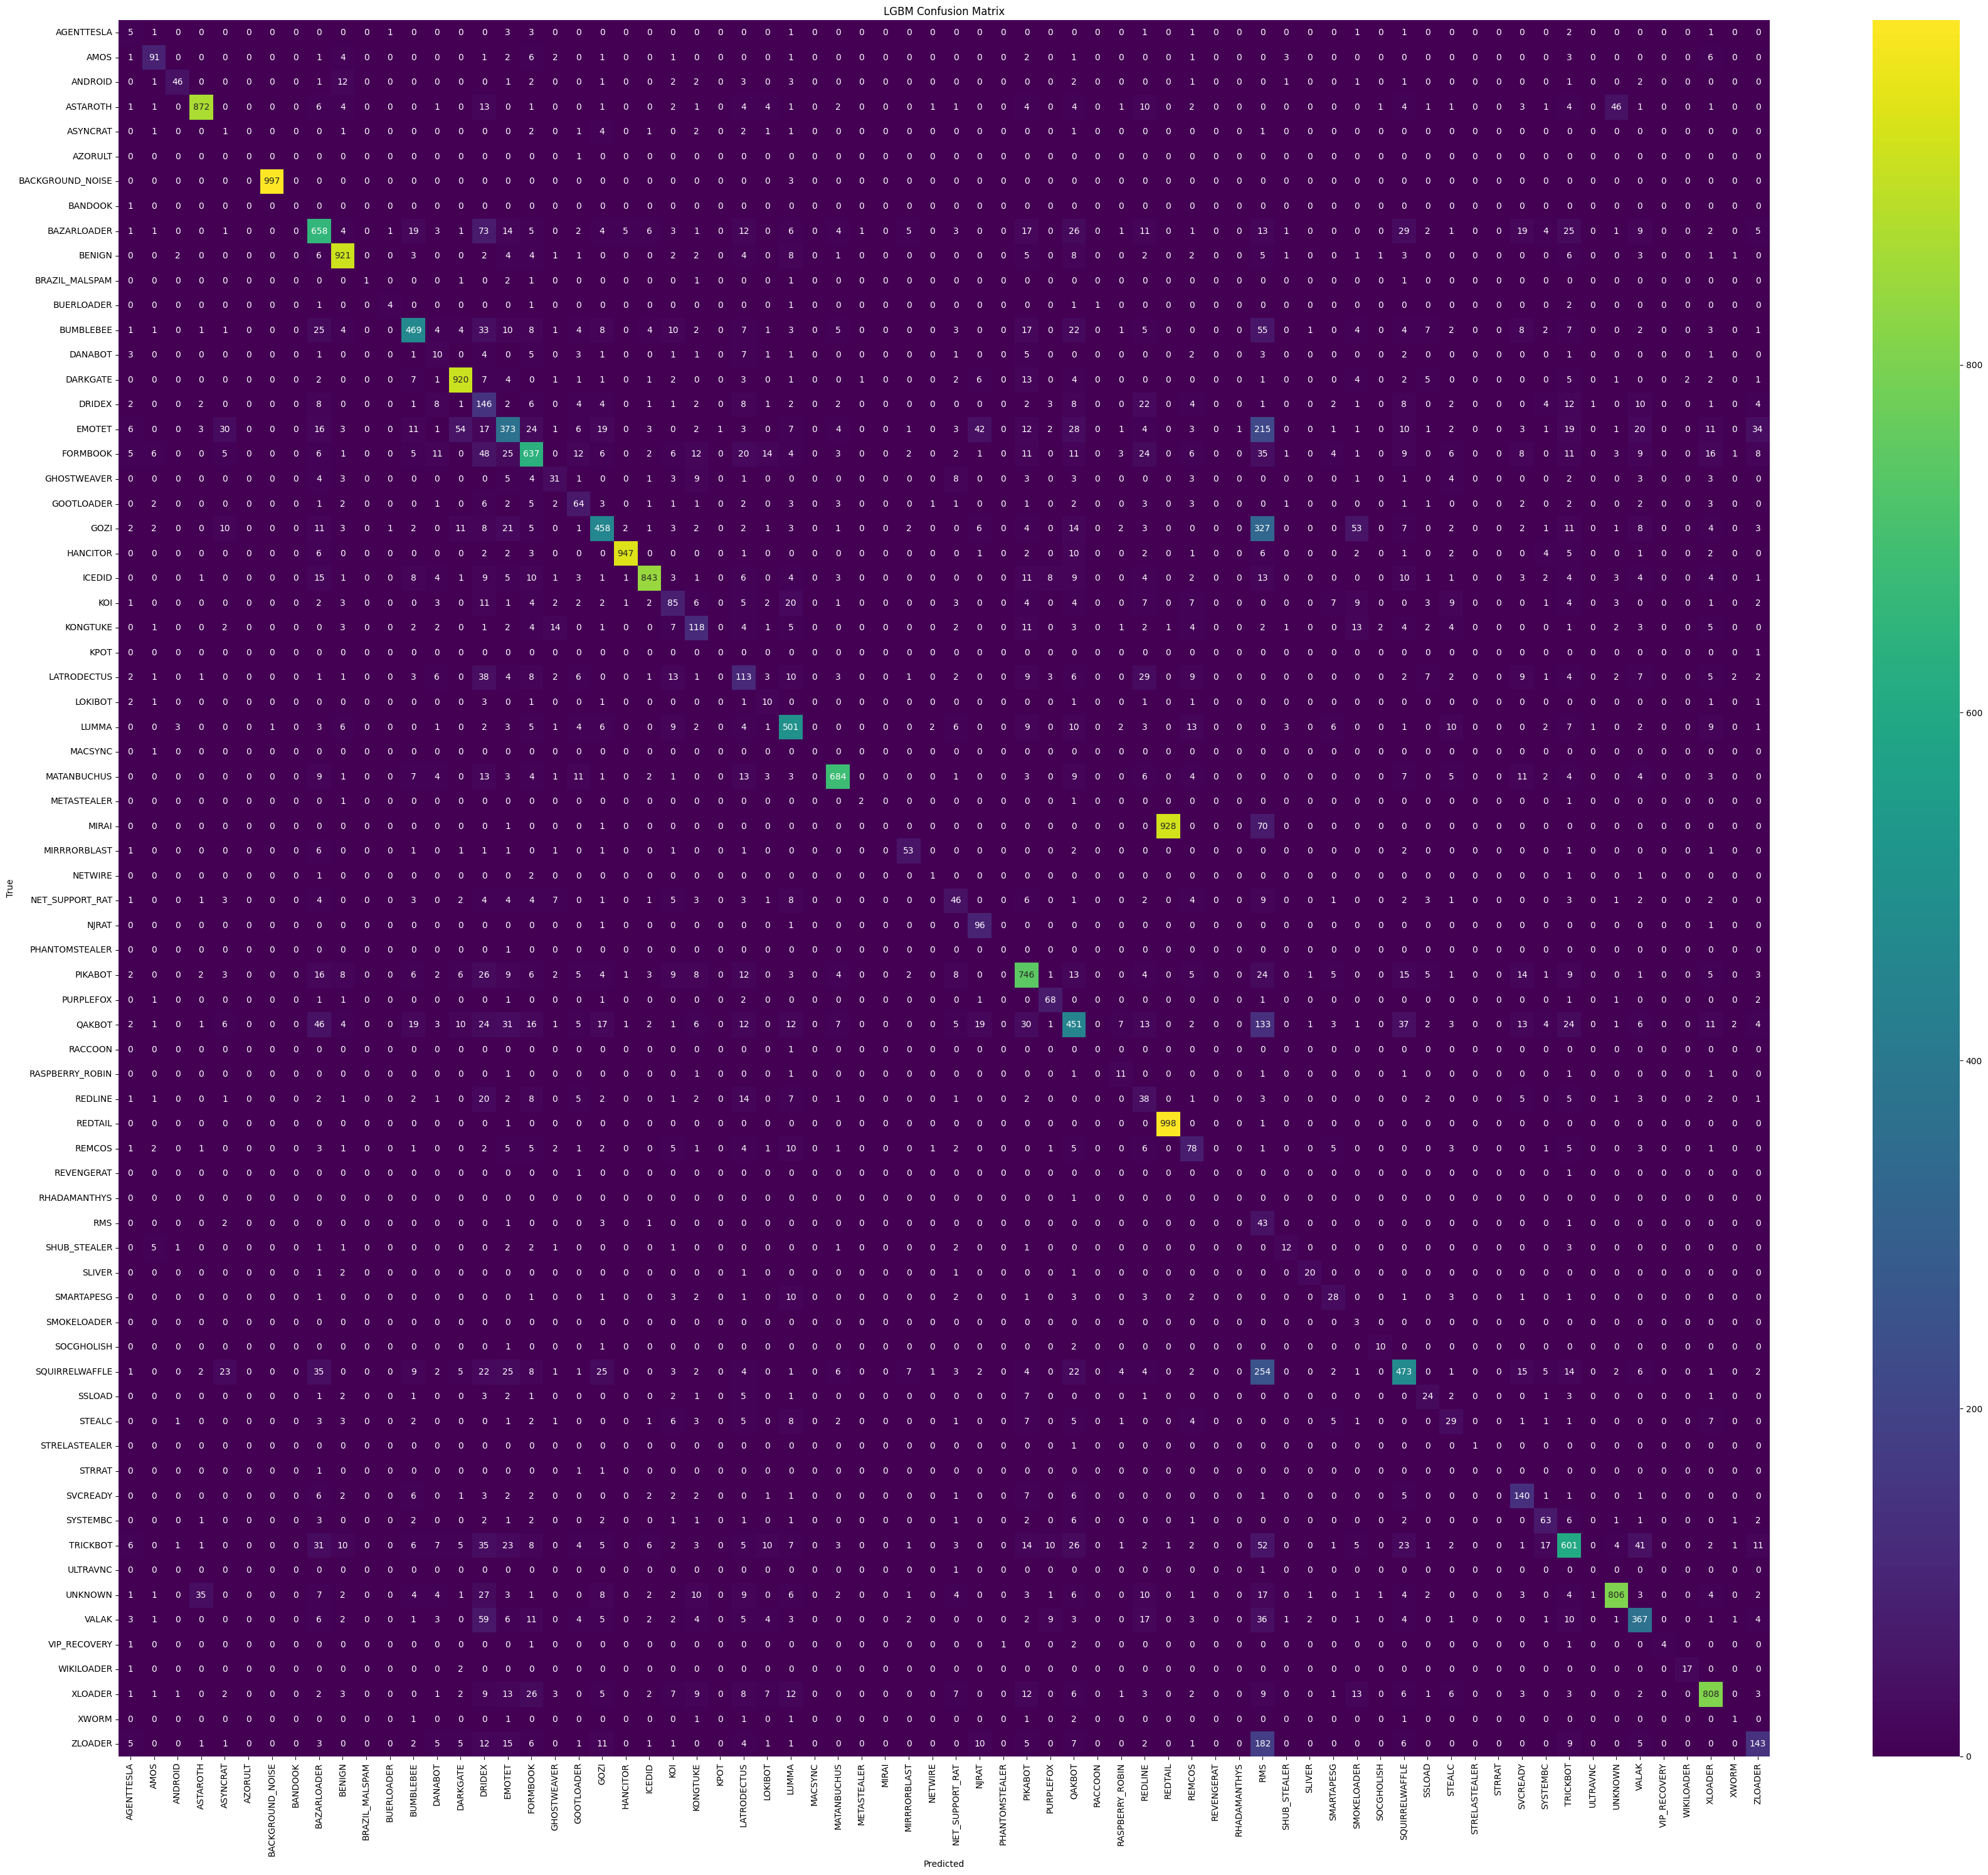

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lgbm.fit(X_train_bal, y_train_bal)
y_pred_lg = lgbm.predict(X_test_sel)
labels = lgbm.classes_   
cm = confusion_matrix(y_test, y_pred_lg, labels=labels)

plt.figure(figsize=(35, 30))

sns.heatmap(
    cm,
    cmap="viridis",   
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("LGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import classification_report
import numpy as np
import plotly.express as px
import pandas as pd


y_pred_lg = lgbm.predict(X_test_sel)
target_names = sorted(set(y_test) | set(y_pred_lg))
metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_lg,
    labels=target_names,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

# Métricas
precision = [
    metrics[c]['precision']
    for c in target_names
]

recall = [
    metrics[c]['recall']
    for c in target_names
]

f1 = [
    metrics[c]['f1-score']
    for c in target_names
]


display_names = [
    'BENIGN' if str(c).startswith('BENIGN') else c
    for c in target_names
]


data = np.array([
    precision,
    recall,
    f1
])


heatmap_df = pd.DataFrame(
    data,
    index=[
        'Precision',
        'Recall',
        'F1-score'
    ],
    columns=display_names
)


fig = px.imshow(
    heatmap_df,
    text_auto='.3f',
    aspect="auto",
    color_continuous_scale='Viridis'
)


fig.update_layout(
    title="LGBM - Classification Report",
    width=2500,
    height=600,
    xaxis=dict(
        tickangle=45
    )
)


fig.write_html(
    "classification_report_LGBM_sintls.html"
)

